## COMP4220: Machine Learning, Fall 2020, Assignment 2


Due: Monday, September 28, 10pm

Please submit one pdf file for all questions.

1. Suppose you are using Polynomial Regression. You plot the learning curves and you notice that there is a large gap between the training error and the validation error. What is happening? What are three ways to solve this?


If the validation error is much higher than the training error, this is likely because
your model is overfitting the training set. One way to try to fix this is to reduce
the polynomial degree: a model with fewer degrees of freedom is less likely to
overfit. Another thing you can try is to regularize the model—for example, by
adding an ℓ2 penalty (Ridge) or an ℓ1 penalty (Lasso) to the cost function. This
will also reduce the degrees of freedom of the model. Lastly, you can try to
increase the size of the training set.


2. How does the Stochastic Gradient Descent algorithm work?



Stochastic gradient descent (SGD) picks a random instance in the training set at every step and computes the
gradients. Unlike batch gradient descent (BGD), SGD bounces around a lot since it picks points at random.
SGD can be good when local minima or plateaus exists in the cost function curve since it's able to jump out of
these areas. SGD has a harder time converging on the ideal solution though since it bounces around, so
implementing a learning schedule that reduces the jump sizes as the time steps increase can help to find the
optimal solution to the cost function.

3. Programming assignment (Linear Regression)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model

Task: Create a two-dimensional plot of regression. This example only uses the first feature of the diabetes dataset, in order to illustrate a two-dimensional plot of linear regression.

In [5]:
# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

In [9]:
# P3.1: Find the number of data instances and features in this data set  
np.shape(diabetes_y) # Numbers of Responses
np.shape(diabetes_X) # Numbers of Predictors (Columns) and Number of Data instances (Rows)
print('There are {} data instances, {} predictors, and {} responses'
      .format(np.shape(diabetes_X)[0],np.shape(diabetes_X)[1],np.shape(diabetes_y)[0]))

There are 442 data instances, 10 predictors, and 442 responses


In [10]:
# Use only one feature
diabetes_X = diabetes_X[:, np.newaxis, 2]
diabetes_X.shape

(442, 1)

In [11]:
# Split the data into training/testing sets
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

In [12]:
# Split the targets into training/testing sets
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

In [14]:
# P3.2: Create linear regression object
from sklearn.linear_model import LinearRegression
regr = LinearRegression() 

In [15]:
# P3.3: Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [16]:
# P3.4: Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)
diabetes_y_pred

array([225.9732401 , 115.74763374, 163.27610621, 114.73638965,
       120.80385422, 158.21988574, 236.08568105, 121.81509832,
        99.56772822, 123.83758651, 204.73711411,  96.53399594,
       154.17490936, 130.91629517,  83.3878227 , 171.36605897,
       137.99500384, 137.99500384, 189.56845268,  84.3990668 ])

In [18]:
# P3.5: Print the coefficients and intercept
coefficients = regr.coef_
intercept = regr.intercept_
print(
'The coefficient is {} and the interception is {}'.format(coefficients[0],intercept))

The coefficient is 938.2378612512633 and the interception is 152.91886182616167


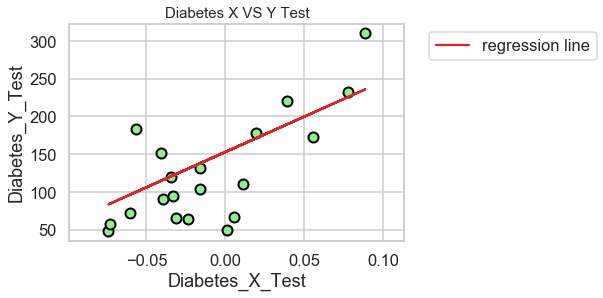

In [19]:
# P3.6: Plot the test data points using plt.scatter and draw "Line of Best Fit" using plt.plot()
# Make sure that you label both axes with appropriate names and save the figure in the png format 
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('talk')
plt.scatter(diabetes_X_test,diabetes_y_test,s=100,color='lightgreen',ec='k',linewidth=2)
plt.plot(diabetes_X_test,diabetes_y_pred,color='tab:red',label='regression line')
plt.ylabel('Diabetes_Y_Test')
plt.xlabel('Diabetes_X_Test')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Diabetes X VS Y Test',fontsize=15)
plt.savefig('LinearRegression.png',dpi=200)


In [20]:
# P3.7: We like to measure the generalization error for the trained model. You can find a wide range of evaluation
# metrics at https://scikit-learn.org/stable/modules/model_evaluation.html
# Pick only one suitable evaluation metric from this list and report the generalization error using the test data set
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
r2 = r2_score(diabetes_y_test, diabetes_y_pred)
MSE = mean_squared_error(diabetes_y_test, diabetes_y_pred)
print('The R^2 for this model is {} and the MSE is {}. Less than ideal...'.format(r2,MSE))

The R^2 for this model is 0.47257544798227136 and the MSE is 2548.0723987259703. Less than ideal...


4. Programming assignment (Polynomial Regression)

Polynomial Regression is appropriate when data are nonlinearly distributed (meaning you can’t ﬁt a straight line between y and x).

Polynomial Regression is linear with respect to coeﬃcients since we don’t have any power of the coeﬃcients (all the coeﬃcients are raised to the power of 1). However, Polynomial Regression is a nonlinear function of the input x, since we have the inputs raised to several powers. 

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv') #the dataset is available in the folder of HW2 on Blackboard
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [3]:
# Training the Linear Regression model on the whole dataset
from sklearn.linear_model import LinearRegression 
lin_reg = LinearRegression()
lin_reg_1 = lin_reg.fit(X, y)
y_pred1 = lin_reg_1.predict(X)
y_pred1                 


array([-114454.54545455,  -33575.75757576,   47303.03030303,
        128181.81818182,  209060.60606061,  289939.39393939,
        370818.18181818,  451696.96969697,  532575.75757576,
        613454.54545455])

In [7]:
# P4.1: Training the Polynomial Regression model on the whole dataset (degree=3)

from sklearn.preprocessing import PolynomialFeatures
# Use "PolynomialFeatures" to generate polynomial features 
poly_features = PolynomialFeatures(degree=3, include_bias=False)
cubic = poly_features.fit_transform(X)
# Solve the linear regression model using the polynomial features 
lin_reg = LinearRegression()
lin_reg_3 = lin_reg.fit(cubic, y)
y_pred3 = lin_reg.predict(cubic)
y_pred3             

array([ 14902.09790209,  78759.9067599 ,  94960.37296037,  88223.77622377,
        83270.3962704 , 104820.51282051, 177594.40559441, 326312.35431236,
       575694.63869464, 950461.53846154])

In [8]:
# P4.2: Training the Polynomial Regression model on the whole dataset (degree=4) as above and call the model lin_reg_4
poly_features = PolynomialFeatures(degree=4, include_bias=False)
quartic = poly_features.fit_transform(X)
# Solve the linear regression model using the polynomial features
lin_reg = LinearRegression()
lin_reg_4 = lin_reg.fit(quartic, y)
y_pred4 = lin_reg.predict(quartic)
y_pred4                      

array([ 53356.64335663,  31759.9067599 ,  58642.19114218,  94632.86713286,
       121724.94172494, 143275.05827506, 184003.4965035 , 289994.17249418,
       528694.63869465, 988916.0839161 ])

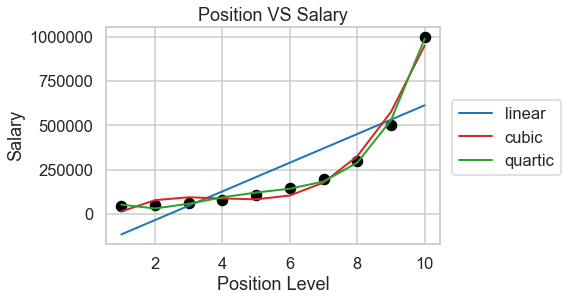

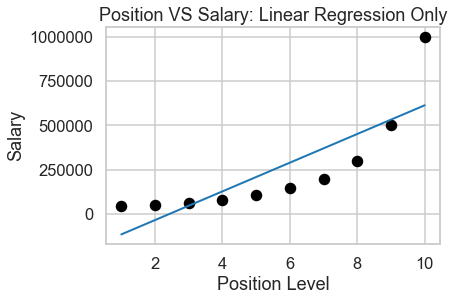

In [9]:
# P4.3: Visualising the Linear Regression results
# Name both axes and don't forget to use "title" as we have several plots 
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('talk')
plt.scatter(X,y,s=100,color='k')
plt.plot(X,y_pred1,color='tab:blue',linewidth=2,label='linear')
plt.plot(X,y_pred3,color='tab:red',linewidth=2,label='cubic')
plt.plot(X,y_pred4,color='tab:green',linewidth=2,label='quartic')
plt.legend(bbox_to_anchor=(1.01, 0.7))
plt.title('Position VS Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()
sns.set_style('whitegrid')
sns.set_context('talk')
plt.scatter(X,y,s=100,color='k')
plt.plot(X,y_pred1,color='tab:blue',linewidth=2,label='linear')
#plt.plot(X,y_pred3,color='tab:red',linewidth=2,label='cubic')
#plt.plot(X,y_pred4,color='tab:green',linewidth=2,label='quartic')
#plt.legend()
plt.title('Position VS Salary: Linear Regression Only')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

How do we ﬁnd the best degree?


The main form of ﬁnding a good ﬁt is to plot the model and see what it looks like visually. You simply test several degrees and you see which one gives you the best ﬁt. The other option is to ﬁnd the lowest root-mean-square error (RMSE) for your model, but in that case be careful not to overﬁt the data.


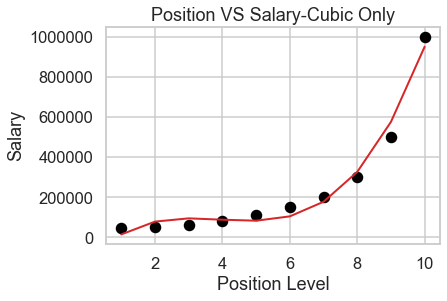

In [10]:
# P4.4: Visualising the Polynomial Regression results (degree = 3)
# Name both axes and don't forget to use "title" as we have several plots 
sns.set_style('whitegrid')
sns.set_context('talk')
plt.scatter(X,y,s=100,color='k')
#plt.plot(X,y_pred1,color='tab:blue',linewidth=2,label='linear')
plt.plot(X,y_pred3,color='tab:red',linewidth=2,label='cubic')
#plt.plot(X,y_pred4,color='tab:green',linewidth=2,label='quartic')
#plt.legend()
plt.title('Position VS Salary-Cubic Only')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

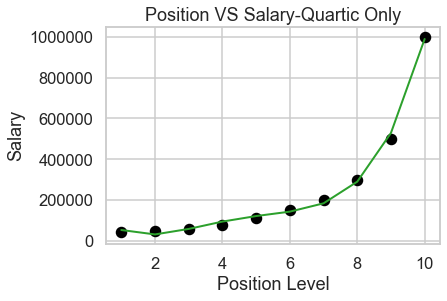

In [11]:
# P4.5: Visualising the Polynomial Regression results (degree = 4)      
# Name both axes and don't forget to use "title" as we have several plots 
sns.set_style('whitegrid')
sns.set_context('talk')
plt.scatter(X,y,s=100,color='k')
#plt.plot(X,y_pred1,color='tab:blue',linewidth=2,label='linear')
#plt.plot(X,y_pred3,color='tab:red',linewidth=2,label='cubic')
plt.plot(X,y_pred4,color='tab:green'
,linewidth=2,label='quartic')
#plt.legend()
plt.title('Position VS Salary-Quartic Only')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

In [12]:
# P4.6: Predicting a new result with Linear Regression when the input is x=19
xpred = np.array([19]).reshape(-1,1)
y_with_19_years= lin_reg_1.predict(xpred)                
print(y_with_19_years)

[1341363.63636364]


In [15]:
# P4.7: Predicting a new result with Polynomial Regression(degree=3) when the input is x=19

poly_features = PolynomialFeatures(degree=3, include_bias=False)
xpred = np.array([19]).reshape(-1,1)
cubic = poly_features.fit_transform(xpred)
y_with_19_years_3d = lin_reg_3.predict(cubic)
print(y_with_19_years_3d)

[14044517.48251747]


In [16]:
# P4.8: Predicting a new result with Polynomial Regression(degree=4) when the input is x=19
poly_features = PolynomialFeatures(degree=4, include_bias=False)
xpred = np.array([19]).reshape(-1,1)
quartic = poly_features.fit_transform(xpred)
y_with_19_years_4d = lin_reg_4.predict(quartic)
print(y_with_19_years_4d)
 

[40328199.30069873]


In [17]:
# P4.9: Please explain the impact of selecting an appropriate degree parameter 
# on generalization error based on the above values?

The generalization error is the "out of sample" error (how well the model can predict
new values). Based on the x=19 predictions from the linear, cubic, and quartic regression
models, it seems the quartic model overfit the training data and isn't useful for prediction given that it's prediction is much higher than the linear or cubic models'
predictions. Based on the three plots, the training error is quite high for the linear
model, lower for the cubic, and the lowest for the quartic. The generalization error is *seemingly* highest for the quartic, then the linear, then the cubic. 

As seen through the prediction values above, the values for the linear regression model and the polynomial regression (degree=3) are
similar. However, the prediction value for polynomial regression (degree=4) is much higher. The predicted value differs greatly from the
training data points. Although the higher degree model fits the training data points well, it does not generalize well and thus is overfitting and
has high generalization error.
Out of the three models used, the polynomial regression (degree=3) seems to work the best in terms of fitting the data well and having a
lower generalization error. The linear regression model underfits the data points, but its generalization error seems to be less polynomial
regression (degree=4).
This demonstrates the concept that decreasing the polynomial degree can reduce overfitting since a model with many degrees of freedom is
likely to have high variance and overfit the training data.